EXPERIMENT 05 - POST LAB
Name    : R. Karthik
Roll No : 25EU02904


PART A - TITANIC CLASSIFICATION

Titanic Dataset Shape:
(891, 12)

First Five Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0 

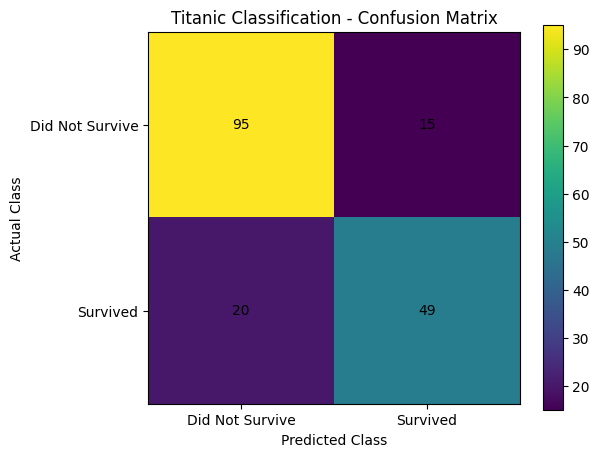



PART B - CALIFORNIA HOUSING REGRESSION

California Housing Dataset Shape:
(20640, 9)

First Five Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

California Housing Regression Results
--------------------------------------
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758


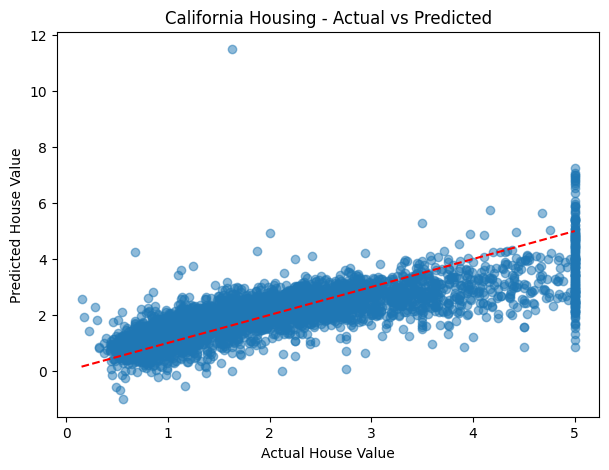


POST-LAB COMPLETED SUCCESSFULLY
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 05 - POST LAB
# Titanic Classification and California Housing Regression
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.datasets import fetch_california_housing


print("=" * 65)
print("EXPERIMENT 05 - POST LAB")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 65)


# ============================================================
# PART A - TITANIC CLASSIFICATION
# ============================================================

print("\n\n" + "=" * 65)
print("PART A - TITANIC CLASSIFICATION")
print("=" * 65)


# Load Titanic dataset
titanic_url = (
    "https://raw.githubusercontent.com/"
    "datasciencedojo/datasets/master/titanic.csv"
)

titanic = pd.read_csv(
    titanic_url
)

print("\nTitanic Dataset Shape:")
print(titanic.shape)

print("\nFirst Five Rows:")
print(titanic.head())


# Select features
titanic_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

X_titanic = titanic[
    titanic_features
].copy()

y_titanic = titanic[
    "Survived"
]


# Handle missing values
X_titanic["Age"] = (
    X_titanic["Age"]
    .fillna(X_titanic["Age"].median())
)

X_titanic["Fare"] = (
    X_titanic["Fare"]
    .fillna(X_titanic["Fare"].median())
)


# Encode Sex
X_titanic["Sex"] = X_titanic["Sex"].map({
    "male": 0,
    "female": 1
})


# Split data
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.20,
    stratify=y_titanic,
    random_state=42
)


# Standardization
scaler_titanic = StandardScaler()

X_train_t_scaled = scaler_titanic.fit_transform(
    X_train_t
)

X_test_t_scaled = scaler_titanic.transform(
    X_test_t
)


# Logistic Regression
titanic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

titanic_model.fit(
    X_train_t_scaled,
    y_train_t
)


# Predictions
titanic_predictions = titanic_model.predict(
    X_test_t_scaled
)


# Metrics
titanic_accuracy = accuracy_score(
    y_test_t,
    titanic_predictions
)

print("\nTitanic Classification Accuracy:")
print(
    f"{titanic_accuracy * 100:.2f}%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_t,
        titanic_predictions,
        target_names=[
            "Did Not Survive",
            "Survived"
        ]
    )
)


# Confusion Matrix
titanic_cm = confusion_matrix(
    y_test_t,
    titanic_predictions
)

print("\nConfusion Matrix:")
print(titanic_cm)

plt.figure(figsize=(6, 5))

plt.imshow(
    titanic_cm,
    interpolation="nearest"
)

plt.title(
    "Titanic Classification - Confusion Matrix"
)

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.yticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            titanic_cm[i, j],
            ha="center",
            va="center"
        )

plt.show()


# ============================================================
# PART B - CALIFORNIA HOUSING REGRESSION
# ============================================================

print("\n\n" + "=" * 65)
print("PART B - CALIFORNIA HOUSING REGRESSION")
print("=" * 65)


# Load California Housing dataset
california = fetch_california_housing(
    as_frame=True
)

california_df = california.frame

print("\nCalifornia Housing Dataset Shape:")
print(california_df.shape)

print("\nFirst Five Rows:")
print(california_df.head())


# Features and target
X_california = california_df.drop(
    "MedHouseVal",
    axis=1
)

y_california = california_df[
    "MedHouseVal"
]


# Split dataset
X_train_ca, X_test_ca, y_train_ca, y_test_ca = train_test_split(
    X_california,
    y_california,
    test_size=0.20,
    random_state=42
)


# Standardization
scaler_ca = StandardScaler()

X_train_ca_scaled = scaler_ca.fit_transform(
    X_train_ca
)

X_test_ca_scaled = scaler_ca.transform(
    X_test_ca
)


# Linear Regression
california_model = LinearRegression()

california_model.fit(
    X_train_ca_scaled,
    y_train_ca
)


# Predictions
california_predictions = california_model.predict(
    X_test_ca_scaled
)


# Metrics
mae = mean_absolute_error(
    y_test_ca,
    california_predictions
)

mse = mean_squared_error(
    y_test_ca,
    california_predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_ca,
    california_predictions
)


print("\nCalifornia Housing Regression Results")
print("--------------------------------------")

print(f"MAE  : {mae:.4f}")

print(f"MSE  : {mse:.4f}")

print(f"RMSE : {rmse:.4f}")

print(f"R²   : {r2:.4f}")


# Actual vs Predicted
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test_ca,
    california_predictions,
    alpha=0.5
)

plt.plot(
    [y_test_ca.min(), y_test_ca.max()],
    [y_test_ca.min(), y_test_ca.max()],
    "r--"
)

plt.xlabel(
    "Actual House Value"
)

plt.ylabel(
    "Predicted House Value"
)

plt.title(
    "California Housing - Actual vs Predicted"
)

plt.show()


# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n" + "=" * 65)
print("POST-LAB COMPLETED SUCCESSFULLY")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 65)